# Commodity Option Strategy Advisor — Crude & LNG

Interactive tool that removes the guesswork from choosing an option structure.

**How it works:** you tell it four things —
1. **Commodity** (WTI Crude, Brent Crude, or LNG/JKM)
2. **Your role** (producer, consumer, or speculator)
3. **Your price view** (bullish / bearish / range-bound / big move either way)
4. **Your premium appetite** (pay for protection, zero-cost, or collect premium)

— and it recommends a specific strategy, prices every leg with **Black-76**, shows the payoff diagram, net Greeks, breakevens, and max profit/loss.

> Run all cells top to bottom, then use the widget panel in **Section 4** (or the manual runner in **Section 5** if widgets are unavailable).

---

## 1. Setup — Pricing Engine (Black-76)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def d1_76(F, K, T, sigma):
    return (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))

def black76_price(F, K, T, r, sigma, opt_type):
    d1 = d1_76(F, K, T, sigma)
    d2 = d1 - sigma * np.sqrt(T)
    disc = np.exp(-r * T)
    if opt_type == 'call':
        return disc * (F * norm.cdf(d1) - K * norm.cdf(d2))
    else:
        return disc * (K * norm.cdf(-d2) - F * norm.cdf(-d1))

def black76_greeks(F, K, T, r, sigma, opt_type):
    """Returns dict: delta, gamma, theta ($/day), vega (per 1% IV)."""
    d1 = d1_76(F, K, T, sigma)
    disc = np.exp(-r * T)
    price = black76_price(F, K, T, r, sigma, opt_type)
    delta = disc * norm.cdf(d1) if opt_type == 'call' else -disc * norm.cdf(-d1)
    gamma = disc * norm.pdf(d1) / (F * sigma * np.sqrt(T))
    vega  = F * disc * norm.pdf(d1) * np.sqrt(T) / 100
    theta = -(F * disc * norm.pdf(d1) * sigma / (2 * np.sqrt(T)) + r * price) / 365
    return {'delta': delta, 'gamma': gamma, 'theta': theta, 'vega': vega, 'price': price}

print("Pricing engine ready.")

Pricing engine ready.


## 2. Commodity Profiles & Strategy Library

Each commodity has realistic defaults (futures price, IV, contract size). **Edit the `COMMODITIES` dict** to match live market levels before making real decisions.

In [2]:
COMMODITIES = {
    'WTI Crude': {
        'F': 80.00, 'sigma': 0.35, 'unit': '$/bbl',
        'contract_size': 1000, 'contract_unit': 'bbl',
        'exchange': 'NYMEX (CL options → LO)',
        'notes': 'Upside vol skew — OTM calls trade rich vs. puts. Watch OPEC meetings and EIA Wednesday storage reports.'
    },
    'Brent Crude': {
        'F': 84.00, 'sigma': 0.33, 'unit': '$/bbl',
        'contract_size': 1000, 'contract_unit': 'bbl',
        'exchange': 'ICE (B options)',
        'notes': 'Global waterborne benchmark; geopolitical premium usually shows up here first.'
    },
    'LNG (JKM)': {
        'F': 12.00, 'sigma': 0.60, 'unit': '$/MMBtu',
        'contract_size': 10000, 'contract_unit': 'MMBtu',
        'exchange': 'ICE / CME JKM futures & options',
        'notes': 'Extremely high and seasonal vol (winter demand, freight, outages). Skew is heavily to the upside — supply shocks can triple prices. Consider wider strikes than you would for crude.'
    },
}

# ── Strategy library ─────────────────────────────────────────────────────────
# Each leg: (option_type, strike_pct_of_F, quantity)  qty >0 = long, <0 = short
# 'fut' legs represent a futures position (for reference strategies).
STRATEGIES = {
    'Long Put': {
        'legs': [('put', 0.95, +1)],
        'summary': 'Buy a put ~5% OTM. Insurance: floor your selling price, keep all upside.',
        'when': 'Producer fearing a fall, or bearish speculator, willing to pay premium.',
        'watch': 'Premium is a sunk cost; high IV (common in LNG) makes this expensive.'
    },
    'Put Spread': {
        'legs': [('put', 0.95, +1), ('put', 0.85, -1)],
        'summary': 'Buy 95% put, sell 85% put. Cheaper downside protection, but the floor stops at the lower strike.',
        'when': 'Moderately bearish view / budget-constrained hedge. You accept re-exposure below the short strike.',
        'watch': 'Protection vanishes below the short strike — size the gap to your worst-case tolerance.'
    },
    'Costless Collar (producer)': {
        'legs': [('put', 0.90, +1), ('call', 1.10, -1)],
        'summary': 'Buy 90% put financed by selling a 110% call. Near-zero net premium: floor at 90%, ceiling at 110%.',
        'when': 'Producer who wants free protection and can live with capped upside.',
        'watch': 'You give away rallies above the call strike — painful in an LNG spike. Strikes here are illustrative; solve for the call strike that makes net premium exactly zero.'
    },
    'Covered Call (vs. physical)': {
        'legs': [('call', 1.08, -1)],
        'summary': 'Sell an ~8% OTM call against physical production/inventory. Collect premium as extra yield.',
        'when': 'Producer with a neutral-to-mildly-bullish view who wants income, not protection.',
        'watch': 'NO downside protection beyond the premium collected. This is yield enhancement, not a hedge.'
    },
    'Long Call': {
        'legs': [('call', 1.05, +1)],
        'summary': 'Buy a call ~5% OTM. Caps your purchase cost, keeps the benefit if prices fall.',
        'when': 'Consumer fearing a spike, or bullish speculator, willing to pay premium.',
        'watch': 'LNG upside skew makes OTM calls expensive — compare against a call spread.'
    },
    'Call Spread': {
        'legs': [('call', 1.05, +1), ('call', 1.20, -1)],
        'summary': 'Buy 105% call, sell 120% call. Cheaper cost cap; protection stops above the upper strike.',
        'when': 'Consumer hedging a moderate spike scenario, or bullish speculator wanting defined risk/reward.',
        'watch': 'In an extreme squeeze (LNG winters), price can blow through the short strike and you are unhedged above it.'
    },
    'Consumer Collar': {
        'legs': [('call', 1.10, +1), ('put', 0.90, -1)],
        'summary': 'Buy 110% call financed by selling a 90% put. Near-zero premium: cost capped at 110%, but you forgo savings below 90%.',
        'when': 'Consumer (airline, utility, importer) wanting zero-cost cost certainty within a band.',
        'watch': 'If prices collapse you are obligated at the put strike — you lose the windfall of cheap fuel.'
    },
    'Cash-Secured Put': {
        'legs': [('put', 0.92, -1)],
        'summary': 'Sell an ~8% OTM put. Collect premium; if assigned, you buy the commodity at an effective discount.',
        'when': 'Consumer happy to buy at lower levels, or neutral-to-bullish premium seller.',
        'watch': 'Full downside exposure below the strike. Only sell puts on volume you genuinely want to own.'
    },
    'Long Straddle': {
        'legs': [('call', 1.00, +1), ('put', 1.00, +1)],
        'summary': 'Buy ATM call + ATM put. Profits from a large move in EITHER direction.',
        'when': 'Speculator expecting a big move (OPEC decision, winter weather, geopolitics) but unsure of direction. Best entered when IV is LOW relative to the expected move.',
        'watch': 'Expensive; double theta bleed. If the event passes quietly, IV crush hits both legs.'
    },
    'Long Strangle': {
        'legs': [('call', 1.08, +1), ('put', 0.92, +1)],
        'summary': 'Buy OTM call + OTM put. Cheaper than a straddle; needs a bigger move to pay off.',
        'when': 'Same thesis as straddle but with less capital; suits high-priced-premium markets like LNG.',
        'watch': 'Wider breakevens — the move must be violent, not just large.'
    },
    'Short Strangle': {
        'legs': [('call', 1.12, -1), ('put', 0.88, -1)],
        'summary': 'Sell OTM call + OTM put. Collect double premium if price stays in the band.',
        'when': 'Speculator with a strong range-bound view and falling-IV expectation (post-event, shoulder season).',
        'watch': 'UNLIMITED risk both directions. In LNG this can be ruinous — one cold snap and the call side explodes. Professionals only, with strict risk limits.'
    },
    'Iron Condor': {
        'legs': [('put', 0.80, +1), ('put', 0.90, -1), ('call', 1.10, -1), ('call', 1.20, +1)],
        'summary': 'Short strangle with protective wings. Defined-risk premium collection in a range.',
        'when': 'Range-bound view but you want a hard cap on losses (the sane version of a short strangle).',
        'watch': 'Lower premium than a naked strangle; commissions on 4 legs. Still hurts if price trends through a wing.'
    },
    'Short Futures (reference)': {
        'legs': [('fut', 1.00, -1)],
        'summary': 'Sell futures outright. Locks the price completely — no premium, no optionality.',
        'when': 'Producer wanting certainty over flexibility. The benchmark every option hedge should be compared against.',
        'watch': 'Gives up ALL upside; margin calls if the market rallies against you.'
    },
    'Long Futures (reference)': {
        'legs': [('fut', 1.00, +1)],
        'summary': 'Buy futures outright. Locks purchase cost completely — no premium, no optionality.',
        'when': 'Consumer wanting certainty over flexibility.',
        'watch': 'Gives up all benefit if prices fall; margin calls in a sell-off.'
    },
}

print(f"{len(COMMODITIES)} commodities, {len(STRATEGIES)} strategies loaded.")

3 commodities, 14 strategies loaded.


## 3. Recommendation Engine + Payoff Analyzer

The decision matrix maps *(role, price view, premium appetite)* → a **primary recommendation** plus alternatives, so you always see what you're trading off.

In [3]:
# ── Decision matrix ──────────────────────────────────────────────────────────
# (role, price_view, premium_appetite) → [primary, alternative, ...]
MATRIX = {
    # ── PRODUCER (long physical: owns barrels / cargoes, fears a price FALL) ──
    ('Producer', 'Bearish / fear a fall',  'Pay premium'):     ['Long Put', 'Put Spread'],
    ('Producer', 'Bearish / fear a fall',  'Zero-cost'):       ['Costless Collar (producer)', 'Put Spread'],
    ('Producer', 'Bearish / fear a fall',  'Collect premium'): ['Costless Collar (producer)', 'Short Futures (reference)'],
    ('Producer', 'Range-bound',            'Pay premium'):     ['Put Spread', 'Long Put'],
    ('Producer', 'Range-bound',            'Zero-cost'):       ['Costless Collar (producer)'],
    ('Producer', 'Range-bound',            'Collect premium'): ['Covered Call (vs. physical)', 'Costless Collar (producer)'],
    ('Producer', 'Bullish / expect rise',  'Pay premium'):     ['Put Spread', 'Long Put'],
    ('Producer', 'Bullish / expect rise',  'Zero-cost'):       ['Put Spread'],
    ('Producer', 'Bullish / expect rise',  'Collect premium'): ['Covered Call (vs. physical)'],
    ('Producer', 'Big move, either way',   'Pay premium'):     ['Long Put', 'Long Strangle'],
    ('Producer', 'Big move, either way',   'Zero-cost'):       ['Costless Collar (producer)'],
    ('Producer', 'Big move, either way',   'Collect premium'): ['Costless Collar (producer)'],

    # ── CONSUMER (short physical: must buy fuel/feedstock, fears a SPIKE) ──
    ('Consumer', 'Bullish / expect rise',  'Pay premium'):     ['Long Call', 'Call Spread'],
    ('Consumer', 'Bullish / expect rise',  'Zero-cost'):       ['Consumer Collar', 'Call Spread'],
    ('Consumer', 'Bullish / expect rise',  'Collect premium'): ['Consumer Collar', 'Long Futures (reference)'],
    ('Consumer', 'Range-bound',            'Pay premium'):     ['Call Spread', 'Long Call'],
    ('Consumer', 'Range-bound',            'Zero-cost'):       ['Consumer Collar'],
    ('Consumer', 'Range-bound',            'Collect premium'): ['Cash-Secured Put', 'Consumer Collar'],
    ('Consumer', 'Bearish / fear a fall',  'Pay premium'):     ['Call Spread'],
    ('Consumer', 'Bearish / fear a fall',  'Zero-cost'):       ['Call Spread'],
    ('Consumer', 'Bearish / fear a fall',  'Collect premium'): ['Cash-Secured Put'],
    ('Consumer', 'Big move, either way',   'Pay premium'):     ['Long Call', 'Long Strangle'],
    ('Consumer', 'Big move, either way',   'Zero-cost'):       ['Consumer Collar'],
    ('Consumer', 'Big move, either way',   'Collect premium'): ['Consumer Collar'],

    # ── SPECULATOR (no physical exposure — pure directional/vol bet) ──
    ('Speculator', 'Bullish / expect rise', 'Pay premium'):     ['Long Call', 'Call Spread'],
    ('Speculator', 'Bullish / expect rise', 'Zero-cost'):       ['Call Spread'],
    ('Speculator', 'Bullish / expect rise', 'Collect premium'): ['Cash-Secured Put', 'Call Spread'],
    ('Speculator', 'Bearish / fear a fall', 'Pay premium'):     ['Long Put', 'Put Spread'],
    ('Speculator', 'Bearish / fear a fall', 'Zero-cost'):       ['Put Spread'],
    ('Speculator', 'Bearish / fear a fall', 'Collect premium'): ['Put Spread'],
    ('Speculator', 'Range-bound',           'Pay premium'):     ['Iron Condor'],
    ('Speculator', 'Range-bound',           'Zero-cost'):       ['Iron Condor'],
    ('Speculator', 'Range-bound',           'Collect premium'): ['Iron Condor', 'Short Strangle'],
    ('Speculator', 'Big move, either way',  'Pay premium'):     ['Long Straddle', 'Long Strangle'],
    ('Speculator', 'Big move, either way',  'Zero-cost'):       ['Long Strangle'],
    ('Speculator', 'Big move, either way',  'Collect premium'): ['Long Strangle'],
}


def leg_payoff(opt_type, K, qty, premium, S_range):
    """P&L of one leg at expiry across a range of settlement prices."""
    if opt_type == 'fut':
        return qty * (S_range - K)
    intrinsic = np.maximum(S_range - K, 0) if opt_type == 'call' else np.maximum(K - S_range, 0)
    return qty * (intrinsic - premium)


def analyze_strategy(strategy_name, commodity_name, T=0.25, r=0.05, show_plot=True):
    """Price all legs with Black-76, print full trade card, plot payoff."""
    c = COMMODITIES[commodity_name]
    strat = STRATEGIES[strategy_name]
    F, sigma, unit = c['F'], c['sigma'], c['unit']
    size = c['contract_size']

    S_range = np.linspace(F * 0.5, F * 1.6, 500)
    total_pnl = np.zeros_like(S_range)
    net_premium = 0.0
    net_greeks = {'delta': 0.0, 'gamma': 0.0, 'theta': 0.0, 'vega': 0.0}
    leg_rows = []

    for opt_type, k_pct, qty in strat['legs']:
        K = round(F * k_pct, 2)
        if opt_type == 'fut':
            premium = 0.0
            g = {'delta': 1.0, 'gamma': 0.0, 'theta': 0.0, 'vega': 0.0}
        else:
            premium = black76_price(F, K, T, r, sigma, opt_type)
            g = black76_greeks(F, K, T, r, sigma, opt_type)
        total_pnl += leg_payoff(opt_type, K, qty, premium, S_range)
        net_premium += qty * premium
        for k in net_greeks:
            net_greeks[k] += qty * g[k]
        side = 'BUY ' if qty > 0 else 'SELL'
        leg_rows.append((side, abs(qty), opt_type.upper(), K, premium))

    # Breakevens: sign changes of payoff
    sign_change = np.where(np.diff(np.sign(total_pnl)) != 0)[0]
    breakevens = [round((S_range[i] + S_range[i+1]) / 2, 2) for i in sign_change]
    max_profit, max_loss = total_pnl.max(), total_pnl.min()

    # ── Trade card ──
    W = 72
    print('═' * W)
    print(f"  {strategy_name.upper()}  on  {commodity_name}")
    print('═' * W)
    print(f"  Market: F={F} {unit} | IV={sigma*100:.0f}% | T={T*12:.0f} months | {c['exchange']}")
    print(f"  {strat['summary']}")
    print('─' * W)
    print(f"  {'Side':<6}{'Qty':>4}  {'Type':<6}{'Strike':>10}  {'Premium':>10}")
    for side, q, t, K, p in leg_rows:
        p_str = f"{p:>10.4f}" if t != 'FUT' else f"{'—':>10}"
        print(f"  {side:<6}{q:>4}  {t:<6}{K:>10.2f}  {p_str}")
    print('─' * W)
    net_lbl = 'you PAY' if net_premium > 0 else 'you COLLECT'
    print(f"  Net premium: {abs(net_premium):.4f} {unit}  ({net_lbl})")
    print(f"  Per contract ({size:,} {c['contract_unit']}): ${abs(net_premium) * size:,.0f} {net_lbl.split()[-1].lower()}")
    if breakevens:
        print(f"  Breakeven(s) at expiry: {', '.join(str(b) for b in breakevens)} {unit}")
    mp = 'unlimited ↑' if max_profit >= total_pnl[-1] and abs(total_pnl[-1] - max_profit) < 1e-9 and strat['legs'][0][0] != 'fut' and max_profit == total_pnl[-1] else f"{max_profit:.2f}"
    print(f"  Max profit: {max_profit:,.2f} {unit}/unit   Max loss: {max_loss:,.2f} {unit}/unit  (within ±50% price range shown)")
    print('─' * W)
    print(f"  Net Greeks (per unit): Δ={net_greeks['delta']:+.3f}  Γ={net_greeks['gamma']:+.4f}  "
          f"Θ={net_greeks['theta']:+.4f}/day  Vega={net_greeks['vega']:+.4f}/1%IV")
    print(f"  When to use: {strat['when']}")
    print(f"  ⚠ Watch out: {strat['watch']}")
    print(f"  Commodity note: {c['notes']}")
    print('═' * W)

    if show_plot:
        fig, ax = plt.subplots(figsize=(9, 4.5))
        ax.plot(S_range, total_pnl, color='navy', linewidth=2)
        ax.fill_between(S_range, total_pnl, 0, where=total_pnl >= 0, color='mediumseagreen', alpha=0.25)
        ax.fill_between(S_range, total_pnl, 0, where=total_pnl < 0,  color='tomato', alpha=0.25)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.axvline(F, color='gray', linestyle='--', alpha=0.7, label=f'Current F = {F}')
        for b in breakevens:
            ax.axvline(b, color='darkorange', linestyle=':', alpha=0.8)
        ax.set_xlabel(f'Settlement Price ({unit})')
        ax.set_ylabel(f'P&L at Expiry ({unit} per unit)')
        ax.set_title(f'{strategy_name} — {commodity_name}  |  payoff at expiry')
        ax.legend()
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()


def recommend(commodity, role, view, premium_appetite, T=0.25, r=0.05):
    """Full advisory flow: look up matrix, analyze the primary pick, list alternatives."""
    key = (role, view, premium_appetite)
    picks = MATRIX.get(key)
    if picks is None:
        print(f"No mapping for {key} — check your inputs.")
        return
    primary, alternatives = picks[0], picks[1:]
    print(f"YOUR SITUATION:  {role} | {view} | {premium_appetite} | {commodity}")
    print(f"RECOMMENDED:     ▶ {primary}")
    if alternatives:
        print(f"ALTERNATIVE(S):    {', '.join(alternatives)}  (run analyze_strategy() on these to compare)")
    print()
    analyze_strategy(primary, commodity, T=T, r=r)

print("Recommendation engine ready.")

Recommendation engine ready.


## 4. Interactive Advisor Panel

Pick your inputs from the dropdowns — the recommendation, trade card, and payoff diagram update automatically.

*(Requires `ipywidgets`. If the panel doesn't render, `pip install ipywidgets` or use Section 5.)*

In [4]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    w_commodity = widgets.Dropdown(options=list(COMMODITIES), value='WTI Crude', description='Commodity:')
    w_role = widgets.Dropdown(
        options=['Producer', 'Consumer', 'Speculator'], value='Producer', description='Your role:')
    w_view = widgets.Dropdown(
        options=['Bearish / fear a fall', 'Bullish / expect rise', 'Range-bound', 'Big move, either way'],
        value='Bearish / fear a fall', description='Price view:')
    w_prem = widgets.Dropdown(
        options=['Pay premium', 'Zero-cost', 'Collect premium'], value='Pay premium', description='Premium:')
    w_tenor = widgets.Dropdown(
        options=[('1 month', 1/12), ('3 months', 0.25), ('6 months', 0.5), ('12 months', 1.0)],
        value=0.25, description='Tenor:')

    out = widgets.Output()

    def refresh(_=None):
        with out:
            clear_output(wait=True)
            recommend(w_commodity.value, w_role.value, w_view.value, w_prem.value, T=w_tenor.value)

    for w in (w_commodity, w_role, w_view, w_prem, w_tenor):
        w.observe(refresh, names='value')

    display(widgets.VBox([
        widgets.HBox([w_commodity, w_role]),
        widgets.HBox([w_view, w_prem, w_tenor]),
        out
    ]))
    refresh()

except ImportError:
    print("ipywidgets not installed — run:  pip install ipywidgets")
    print("Then restart the kernel. Meanwhile, use the manual runner in Section 5.")

ipywidgets not installed — run:  pip install ipywidgets
Then restart the kernel. Meanwhile, use the manual runner in Section 5.


## 5. Manual Runner (no widgets needed)

Edit the four inputs and run the cell.

YOUR SITUATION:  Consumer | Bullish / expect rise | Zero-cost | LNG (JKM)
RECOMMENDED:     ▶ Consumer Collar
ALTERNATIVE(S):    Call Spread  (run analyze_strategy() on these to compare)

════════════════════════════════════════════════════════════════════════
  CONSUMER COLLAR  on  LNG (JKM)
════════════════════════════════════════════════════════════════════════
  Market: F=12.0 $/MMBtu | IV=60% | T=6 months | ICE / CME JKM futures & options
  Buy 110% call financed by selling a 90% put. Near-zero premium: cost capped at 110%, but you forgo savings below 90%.
────────────────────────────────────────────────────────────────────────
  Side   Qty  Type      Strike     Premium
  BUY      1  CALL       13.20      1.5304
  SELL     1  PUT        10.80      1.3391
────────────────────────────────────────────────────────────────────────
  Net premium: 0.1913 $/MMBtu  (you PAY)
  Per contract (10,000 MMBtu): $1,913 pay
  Breakeven(s) at expiry: 13.39 $/MMBtu
  Max profit: 5.81 $/MMBtu/unit   M

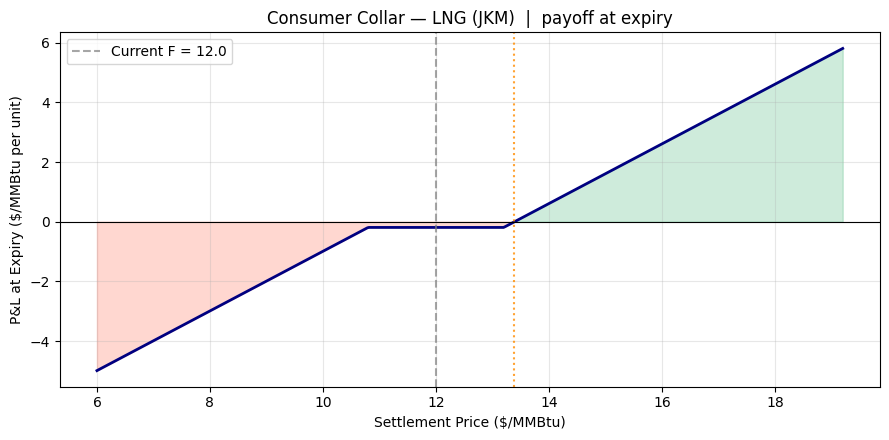

In [5]:
recommend(
    commodity        = 'LNG (JKM)',              # 'WTI Crude' | 'Brent Crude' | 'LNG (JKM)'
    role             = 'Consumer',                # 'Producer' | 'Consumer' | 'Speculator'
    view             = 'Bullish / expect rise',   # 'Bearish / fear a fall' | 'Bullish / expect rise' | 'Range-bound' | 'Big move, either way'
    premium_appetite = 'Zero-cost',               # 'Pay premium' | 'Zero-cost' | 'Collect premium'
    T                = 0.5,                       # tenor in years
)

You can also analyze any strategy directly, bypassing the recommender — useful for comparing the primary pick against its alternatives:

════════════════════════════════════════════════════════════════════════
  CALL SPREAD  on  LNG (JKM)
════════════════════════════════════════════════════════════════════════
  Market: F=12.0 $/MMBtu | IV=60% | T=6 months | ICE / CME JKM futures & options
  Buy 105% call, sell 120% call. Cheaper cost cap; protection stops above the upper strike.
────────────────────────────────────────────────────────────────────────
  Side   Qty  Type      Strike     Premium
  BUY      1  CALL       12.60      1.7358
  SELL     1  CALL       14.40      1.1855
────────────────────────────────────────────────────────────────────────
  Net premium: 0.5503 $/MMBtu  (you PAY)
  Per contract (10,000 MMBtu): $5,503 pay
  Breakeven(s) at expiry: 13.16 $/MMBtu
  Max profit: 1.25 $/MMBtu/unit   Max loss: -0.55 $/MMBtu/unit  (within ±50% price range shown)
────────────────────────────────────────────────────────────────────────
  Net Greeks (per unit): Δ=+0.122  Γ=+0.0014  Θ=-0.0002/day  Vega=+0.0006/1%IV
  When

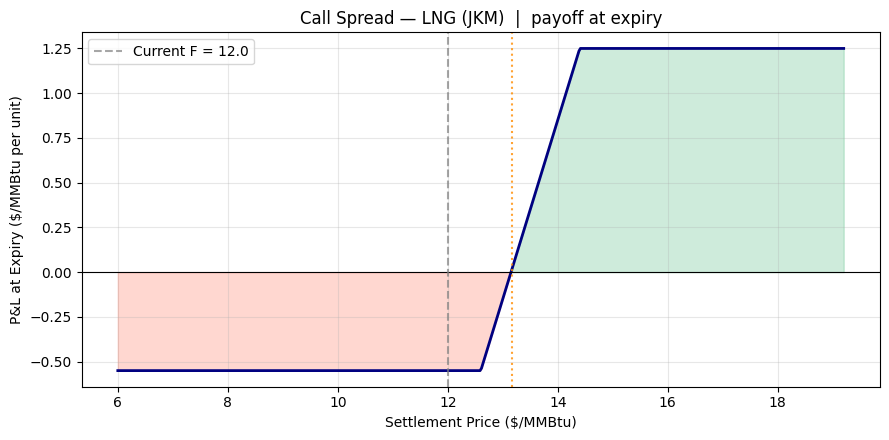

════════════════════════════════════════════════════════════════════════
  CONSUMER COLLAR  on  LNG (JKM)
════════════════════════════════════════════════════════════════════════
  Market: F=12.0 $/MMBtu | IV=60% | T=6 months | ICE / CME JKM futures & options
  Buy 110% call financed by selling a 90% put. Near-zero premium: cost capped at 110%, but you forgo savings below 90%.
────────────────────────────────────────────────────────────────────────
  Side   Qty  Type      Strike     Premium
  BUY      1  CALL       13.20      1.5304
  SELL     1  PUT        10.80      1.3391
────────────────────────────────────────────────────────────────────────
  Net premium: 0.1913 $/MMBtu  (you PAY)
  Per contract (10,000 MMBtu): $1,913 pay
  Breakeven(s) at expiry: 13.39 $/MMBtu
  Max profit: 5.81 $/MMBtu/unit   Max loss: -4.99 $/MMBtu/unit  (within ±50% price range shown)
────────────────────────────────────────────────────────────────────────
  Net Greeks (per unit): Δ=+0.797  Γ=+0.0077  Θ=-0.00

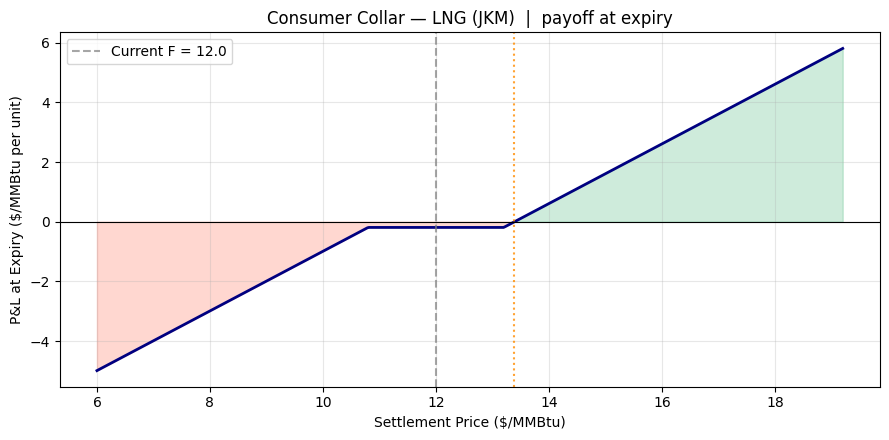

In [6]:
# Example: compare the two consumer hedges side by side
analyze_strategy('Call Spread', 'LNG (JKM)', T=0.5)
analyze_strategy('Consumer Collar', 'LNG (JKM)', T=0.5)

---
## 6. Decision Matrix Reference

The full logic the advisor uses, for offline reference:

### Producer (long physical — owns crude barrels / LNG cargoes, fears a price FALL)

| Price view | Pay premium | Zero-cost | Collect premium |
|---|---|---|---|
| Bearish | **Long Put** | **Costless Collar** | Collar |
| Range-bound | Put Spread | Collar | **Covered Call** |
| Bullish | Put Spread (cheap insurance) | Put Spread | Covered Call |
| Big move either way | Long Put | Collar | Collar |

### Consumer (short physical — must buy fuel/feedstock, fears a SPIKE)

| Price view | Pay premium | Zero-cost | Collect premium |
|---|---|---|---|
| Bullish | **Long Call** | **Consumer Collar** | Collar |
| Range-bound | Call Spread | Collar | **Cash-Secured Put** |
| Bearish | Call Spread (cheap insurance) | Call Spread | Cash-Secured Put |
| Big move either way | Long Call | Collar | Collar |

### Speculator (no physical exposure)

| Price view | Pay premium | Zero-cost | Collect premium |
|---|---|---|---|
| Bullish | **Long Call** | Call Spread | Cash-Secured Put |
| Bearish | **Long Put** | Put Spread | Put Spread |
| Range-bound | Iron Condor | Iron Condor | **Iron Condor / Short Strangle** |
| Big move either way | **Long Straddle** | Long Strangle | Long Strangle |

### Crude vs. LNG — practical differences

| Factor | Crude (WTI/Brent) | LNG (JKM) |
|---|---|---|
| Typical IV | 25–60% | 40–150%, extreme in winter |
| Skew | Moderate upside skew | Heavy upside skew — OTM calls very rich |
| Premium selling | Reasonable risk/reward | Dangerous on the call side (spike risk) |
| Collar strikes | ±10% works | Consider asymmetric strikes (wider call side) |
| Liquidity | Deep, tight spreads | Thinner; wider bid/ask, use limit orders |
| Seasonality | Mild (driving season) | Severe (winter heating, summer cooling in Asia) |

> **Disclaimer:** default prices and vols in `COMMODITIES` are illustrative. Update them to live market levels, and treat the output as a structured starting point — not trade advice.